# 1. Perkenalan

Nama : Aulia Putri

Dataset : [Telco Customer Churn Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/code)

Dataset ini berisi informasi pelanggan perusahaan telekomunikasi, seperti data demografi pelanggan, jenis layanan yang digunakan, biaya layanan, metode pembayaran, lama berlangganan (*tenure*), hingga status pelanggan melakukan churn atau tidak. Dataset ini digunakan untuk menganalisis faktor-faktor yang memengaruhi churn pelanggan serta membangun model machine learning untuk memprediksi kemungkinan pelanggan berhenti berlangganan.

Beberapa fitur penting pada dataset antara lain:

- tenur : lama pelanggan menggunakan layanan perusahaan.
- MonthlyCharges : total biaya bulanan yang dibayarkan pelanggan.
- TotalCharges : total keseluruhan biaya yang telah dibayarkan pelanggan.
- Contract : jenis kontrak pelanggan.
- InternetService : jenis layanan internet yang digunakan pelanggan.
- PaymentMethod : metode pembayaran pelanggan.
- Churn : status pelanggan berhenti berlangganan atau tidak.

## 1.1 Problem

Industri telekomunikasi merupakan salah satu industri dengan tingkat persaingan yang cukup tinggi. Pelanggan dapat dengan mudah berpindah ke layanan kompetitor apabila merasa layanan yang diberikan kurang sesuai dengan kebutuhan mereka. Kondisi tersebut menyebabkan perusahaan perlu memahami faktor-faktor yang memengaruhi *customer churn* agar dapat mempertahankan pelanggan dengan lebih baik.

Tingginya tingkat churn dapat memberikan dampak negatif bagi perusahaan, seperti:

- Kerugian finansial akibat kehilangan pelanggan.
- Penurunan pertumbuhan bisnis.
- Meningkatnya biaya untuk mendapatkan pelanggan baru.
- Strategi pemasaran dan retensi menjadi kurang efektif apabila perusahaan tidak mengetahui pelanggan yang berisiko churn.

Oleh karena itu, diperlukan model machine learning yang mampu membantu perusahaan mengidentifikasi pelanggan yang berpotensi churn sehingga perusahaan dapat melakukan strategi retensi yang lebih tepat sasaran.

## 1.2 Objective (SMART)

### 1.2.1 Specific
Membangun model machine learning untuk memprediksi apakah pelanggan akan melakukan churn atau tidak berdasarkan karakteristik pelanggan dan layanan yang digunakan.

### 1.2.2 Measurable
Performa model akan dievaluasi menggunakan beberapa metrics, yaitu:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Fokus utama evaluasi diarahkan pada Recall dan F1-Score karena kasus churn prediction memiliki kondisi data imbalance dan perusahaan perlu meminimalkan pelanggan churn yang tidak terdeteksi.

### 1.2.3 Achievable
Model akan dibangun menggunakan beberapa algoritma machine learning seperti:
- KNN
- SVM
- Decision Tree
- Random Forest
- Gradient Boosting

Selain itu, akan dilakukan preprocessing, balancing data, cross validation, dan hyperparameter tuning untuk meningkatkan performa model.

### 1.2.4 Relevant
Project ini diharapkan dapat membantu perusahaan telekomunikasi dalam:
- Memahami faktor utama penyebab churn pelanggan.
- Menentukan strategi customer retention yang lebih efektif.
- Membantu pengambilan keputusan berbasis data terkait loyalitas pelanggan.

### 1.2.5 Time-bound
Project diselesaikan melalui beberapa tahapan, yaitu:
- Data Loading & Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Modeling
- Evaluation
- Inference
- Kesimpulan & Recommendation

## 1.3 Expected Output

Output yang diharapkan dari project ini antara lain:

- Model machine learning untuk memprediksi churn pelanggan.
- Insight mengenai faktor-faktor yang memengaruhi churn pelanggan.
- Visualisasi hasil analisis dan evaluasi model.
- Rekomendasi strategi retensi pelanggan berdasarkan hasil analisis model.

## 1.4 Target User

Project ini ditujukan untuk:
- Perusahaan telekomunikasi
- Tim marketing dan customer retention
- Data analyst
- Business analyst

## 1.5 Deployment URL

[telco_customer_churn_prediction](https://huggingface.co/spaces/Awliaputri/telco_customer_churn_prediction)

# 2. Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
import pickle

# 3. Data Loading

## 3.1 Load Dataset

In [2]:
# load data
df = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
# menampilakan baris pertama
print(50 * "=", " 5 Data Pertama ", 50*"=")
display(df.head())

# menampilkan baris terakhir
print(50 * "=", " 5 Data Terakhir ", 50*"=")
display(df.tail())

==================================================  5 Data Pertama  ==================================================


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


==================================================  5 Data Terakhir  ==================================================


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [4]:
# information
print(20*'=', "Informasi Dataset", 20*'=')
df.info()

==================== Informasi Dataset ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-nu

Insight:
>- Dataset terdiri dari 7.043 data dengan 21 kolom tanpa missing value. Sebagian besar kolom bertipe kategorikal (object), seperti layanan, kontrak, dan metode pembayaran, sementara hanya beberapa kolom yang numerik seperti tenure dan MonthlyCharges. Kolom SeniorCitizen meskipun berupa angka sebenarnya merepresentasikan kategori. 
>
>- Selain itu, TotalCharges masih bertipe object padahal seharusnya numerik, sehingga perlu dikonversi. Kolom Churn sebagai target juga masih berbentuk kategori (Yes/No) dan perlu diubah ke numerik. Oleh karena itu, langkah selanjutnya adalah melakukan data cleaning dan preprocessing.

In [5]:
# summary statistik
print(20*'=', "Statistik", 20*'=')
display(df.describe())

==================== Statistik ====================


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Insight:
>- Nilai rata-rata tenure berada di sekitar 32 bulan, dengan median 29 bulan. Hal ini menunjukkan bahwa sebagian besar pelanggan berada pada kategori pelanggan dengan masa berlangganan menengah, tidak terlalu baru namun juga belum terlalu lama.
>
>- Pada fitur MonthlyCharges, rata-rata biaya bulanan berada di sekitar 64.76, dengan rentang yang cukup lebar dari 18 hingga 118. Hal ini menunjukkan adanya variasi paket layanan yang digunakan pelanggan, dari yang relatif murah hingga yang lebih mahal.
>
>- Nilai minimum tenure yang mencapai 0 menunjukkan adanya pelanggan baru yang belum lama bergabung, yang nantinya berpotensi memiliki perilaku churn yang berbeda dibanding pelanggan lama.
>
>- Untuk fitur SeniorCitizen, rata-rata sebesar 0.16 menunjukkan bahwa sebagian besar pelanggan bukan merupakan lansia. Hal ini berarti distribusi pelanggan lebih didominasi oleh kelompok non-senior.

In [6]:
# melihat daftar nama kolom
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Insight:
>- Dataset memiliki 21 kolom yang mencakup informasi pelanggan, layanan yang digunakan, serta biaya dan metode pembayaran.
>
>- Kolom customerID hanya sebagai identitas, sehingga tidak akan digunakan dalam pemodelan.
>
>- Kolom Churn merupakan target utama untuk menentukan apakah pelanggan berhenti berlangganan atau tidak.

## 3.2 Duplicate Checking

In [7]:
# mengecek data duplikat
print(f"Duplicates Before : {df.duplicated().sum()}")# mengecek data duplikat

Duplicates Before : 0


In [8]:
# menghapus kolom cust id
df.drop(columns=['customerID'], inplace=True)

Insight:

> Kolom customerID dihapus karena hanya berfungsi sebagai identitas unik pelanggan dan tidak memiliki pengaruh terhadap proses analisis maupun pemodelan.

In [9]:
# mengecek data duplikat
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 22


Insight:

> Tidak ditemukan data duplikat ketika kolom customerID masih digunakan. Namun, setelah kolom tersebut dihapus, muncul 22 baris data yang memiliki nilai yang sama pada seluruh fitur. Hal ini menunjukkan bahwa data tersebut bukan merupakan duplikat, melainkan pelanggan yang berbeda tetapi memiliki karakteristik yang identik. Oleh karena itu, data tidak dihapus agar tidak mengurangi representasi dataset.

## 3.3 Data Type Conversion

In [10]:
# mengubah target menjadi numerik
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# mengubah kolom TotalCharges menjadi numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

## 3.4 Missing Value Check & Handling

In [11]:
# mengecek jumlah missing value pada setiap kolom
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Insight:

> Secara umum dataset tidak memiliki missing value pada hampir semua kolom. Namun, terdapat 11 data kosong pada kolom TotalCharges. Jumlah ini relatif kecil dibandingkan total data, tetapi tetap perlu ditangani karena kolom tersebut merupakan fitur numerik yang penting dalam analisis.

In [12]:
# pengecekan pola missing
df[df['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


Insight:
> Berdasarkan pengecekan pola missing values, seluruh missing value pada kolom TotalCharges terjadi pada pelanggan dengan nilai tenure = 0. Hal ini menunjukkan bahwa pelanggan belum memiliki total tagihan karena baru mulai berlangganan. Oleh karena itu, missing value pada kolom TotalCharges tidak terjadi secara acak sepenuhnya, melainkan dipengaruhi oleh fitur lain yaitu tenure, sehingga pola missing cenderung termasuk Missing At Random (MAR).

In [13]:
# imputasi missing value menggunakan median
median_total = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total)

# cek missing value after handling
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Insight:

> Untuk menangani missing value, dilakukan imputasi menggunakan nilai median pada kolom TotalCharges. Median dipilih karena lebih stabil terhadap outlier dibandingkan mean, sehingga dapat membantu menjaga distribusi data tetap lebih baik. Setelah proses imputasi dilakukan, seluruh missing value pada dataset berhasil ditangani.

# 4. Exploratory Data Analysis (EDA)

## 4.1 Distribusi Churn (Target)

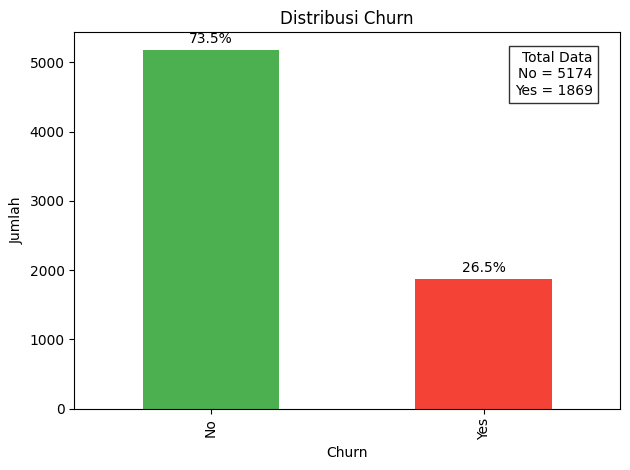

In [14]:
# hitung jumlah & persentase
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

# rename biar readable
label_map = {0: 'No', 1: 'Yes'}
churn_counts.index = churn_counts.index.map(label_map)
churn_percent.index = churn_percent.index.map(label_map)

# plot
fig, ax = plt.subplots()
churn_counts.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'])

# tambahkan persentase
for i, (count, pct) in enumerate(zip(churn_counts, churn_percent)):
    ax.text(i, count + (churn_counts.max()*0.02),
            f"{pct:.1f}%", ha='center', fontsize=10)

# kotak info
text = f"Total Data\nNo = {churn_counts['No']}\nYes = {churn_counts['Yes']}"
ax.text(0.95, 0.95, text,
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

# label
plt.title('Distribusi Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah')

plt.tight_layout()
plt.show()

Insight:
>- Berdasarkan distribusi data, jumlah pelanggan yang tidak melakukan churn sebanyak 73.5% (5.174) jauh lebih banyak dibandingkan pelanggan yang churn sebanyak 26.5% (1.869). Hal ini menunjukkan bahwa dataset memiliki ketidakseimbangan kelas, di mana pelanggan yang tetap berlangganan mendominasi. Kondisi ini perlu diperhatikan pada tahap modeling agar model tidak bias terhadap kelas mayoritas.
>
>- Hal ini menunjukkan bahwa dataset memiliki ketidakseimbangan kelas (imbalanced), di mana kelas mayoritas adalah pelanggan yang tidak churn. Kondisi ini perlu diperhatikan pada tahap pemodelan karena model berpotensi lebih condong memprediksi kelas mayoritas.

## 4.2 Churn Berdasarkan Gender

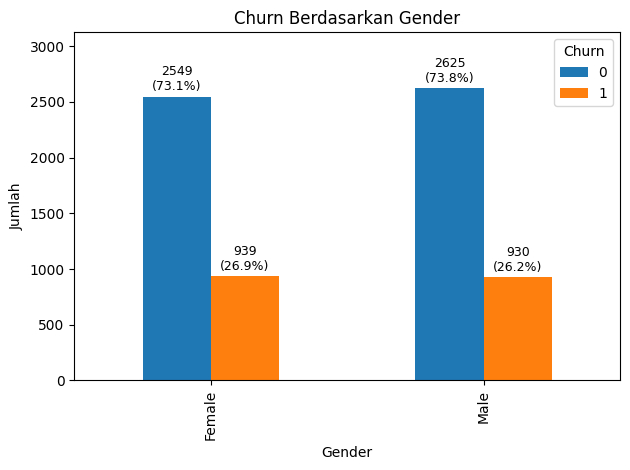

In [15]:
# crosstab
ct = pd.crosstab(df['gender'], df['Churn'])
ct_pct = pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100

# plot
ax = ct.plot(kind='bar')

# ambil posisi bar yang asli
for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2

    # cari index untuk ambil persen
    gender_idx = int(p.get_x() + p.get_width() / 2)
    
    # cari label berdasarkan tinggi
    for gender in ct.index:
        for churn in ct.columns:
            if ct.loc[gender, churn] == height:
                pct = ct_pct.loc[gender, churn]
    
    ax.text(x, height + 30, f"{int(height)}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=9)

# label
max_val = ct.values.max()
plt.ylim(0, max_val + 500)
plt.title('Churn Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

Insight:
> Proporsi churn antara pelanggan laki-laki dan perempuan relatif seimbang, sehingga gender kemungkinan bukan variabel yang memiliki pengaruh signifikan terhadap churn dibandingkan faktor layanan atau kontrak pelanggan.

## 4.3 Churn Berdasarkan SeniorCitizen

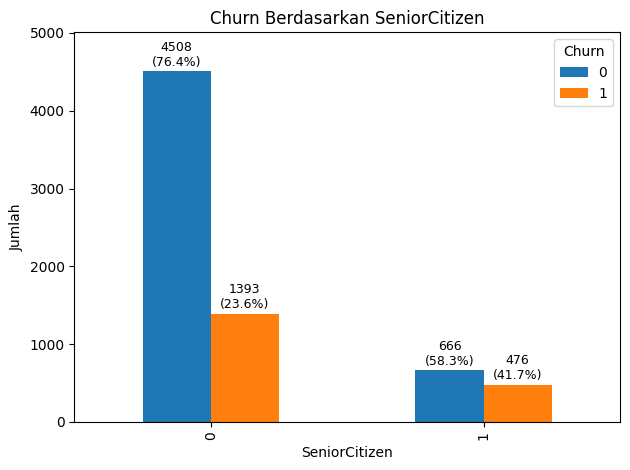

In [16]:
# crosstab
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])
ct_pct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# plot
ax = ct.plot(kind='bar')

# ambil posisi bar yang asli
for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2

    # cari index untuk ambil persen
    SC_idx = int(p.get_x() + p.get_width() / 2)
    
    # cari label berdasarkan tinggi
    for sc in ct.index:
        for churn in ct.columns:
            if ct.loc[sc, churn] == height:
                pct = ct_pct.loc[sc, churn]
    
    ax.text(x, height + 30, f"{int(height)}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=9)

# label
max_val = ct.values.max()
plt.ylim(0, max_val + 500)
plt.title('Churn Berdasarkan SeniorCitizen')
plt.xlabel('SeniorCitizen')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

Insight:
> Pelanggan yang bukan senior (0) memang mendominasi jumlah data, namun proporsi churn pada kelompok ini relatif lebih rendah (sekitar 23.6%). Sebaliknya, pelanggan senior (1) memiliki proporsi churn yang lebih tinggi, yaitu sekitar 41.7%. Hal ini menunjukkan bahwa pelanggan senior cenderung lebih berisiko untuk melakukan churn dibandingkan non-senior.

## 4.4 Churn Berdasarkan Partner

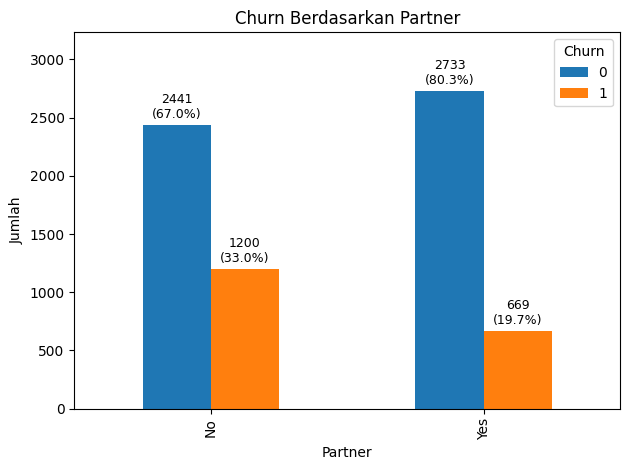

In [17]:
# crosstab
ct = pd.crosstab(df['Partner'], df['Churn'])
ct_pct = pd.crosstab(df['Partner'], df['Churn'], normalize='index') * 100

# plot
ax = ct.plot(kind='bar')

# ambil posisi bar yang asli
for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2

    # cari index untuk ambil persen
    partner_idx = int(p.get_x() + p.get_width() / 2)
    
    # cari label berdasarkan tinggi
    for partner in ct.index:
        for churn in ct.columns:
            if ct.loc[partner, churn] == height:
                pct = ct_pct.loc[partner, churn]
    
    ax.text(x, height + 30, f"{int(height)}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=9)

# label
max_val = ct.values.max()
plt.ylim(0, max_val + 500)
plt.title('Churn Berdasarkan Partner')
plt.xlabel('Partner')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

Insight:
> Pelanggan yang tidak memiliki partner menunjukkan proporsi churn yang lebih tinggi (33%) dibandingkan pelanggan yang memiliki partner (19.7%). Hal ini menunjukkan bahwa pelanggan dengan partner cenderung lebih stabil dan memiliki kemungkinan churn yang lebih rendah.

## 4.5 Churn Berdasarkan Tenure

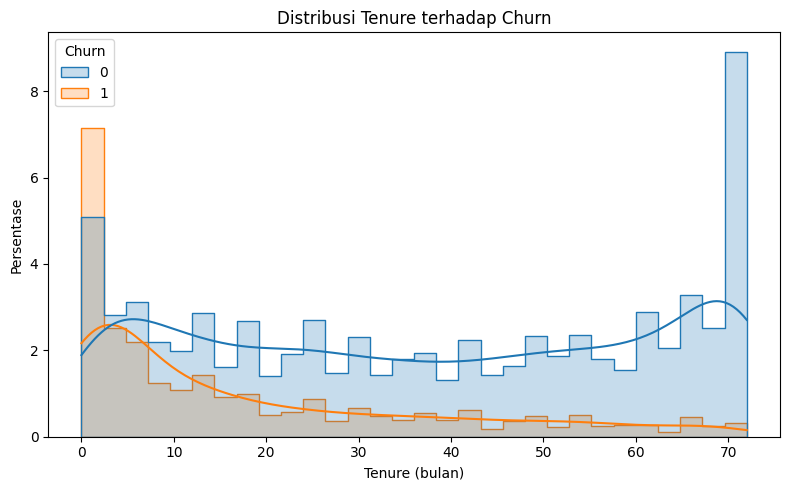

In [18]:
# mengatur ukuran figure agar visualisasi lebih jelas
plt.figure(figsize=(8,5))

# membuat histogram distribusi tenure berdasarkan status churn
sns.histplot(

    # dataset yang digunakan
    data=df,

    # kolom yang dianalisis pada sumbu x
    x='tenure',

    # membedakan warna berdasarkan status churn
    hue='Churn',

    # jumlah interval histogram
    bins=30,

    # menampilkan distribusi dalam bentuk persentase
    stat='percent',

    # menampilkan garis kepadatan distribusi (kernel density estimation)
    kde=True,

    # membuat tampilan histogram berbentuk outline/step
    element='step'
)

# menambahkan judul visualisasi
plt.title('Distribusi Tenure terhadap Churn')

# memberi label pada sumbu x
plt.xlabel('Tenure (bulan)')

# memberi label pada sumbu y
plt.ylabel('Persentase')

# merapikan layout agar tidak bertumpuk
plt.tight_layout()

# menampilkan visualisasi
plt.show()

Insight:
> Pelanggan dengan tenure rendah (baru bergabung) terlihat lebih banyak melakukan churn. Sebaliknya, pelanggan dengan tenure yang lebih lama cenderung tetap bertahan. Hal ini menunjukkan bahwa semakin lama pelanggan menggunakan layanan, semakin kecil kemungkinan mereka untuk churn.

## 4.6 Churn Berdasarkan Contract

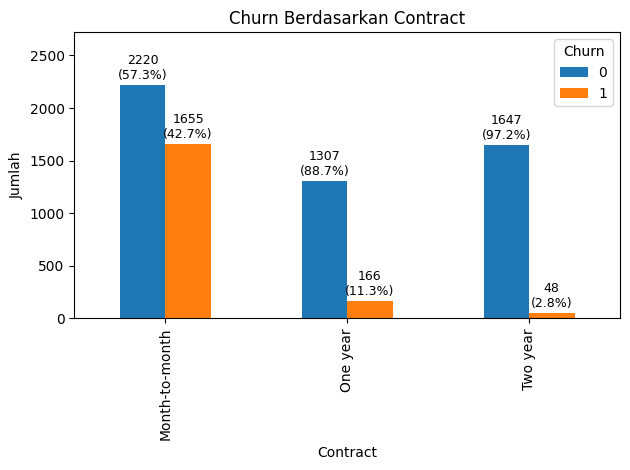

In [19]:
# crosstab
ct = pd.crosstab(df['Contract'], df['Churn'])
ct_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

# plot
ax = ct.plot(kind='bar')

# ambil posisi bar yang asli
for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2

    # cari index untuk ambil persen
    partner_idx = int(p.get_x() + p.get_width() / 2)
    
    # cari label berdasarkan tinggi
    for cnt in ct.index:
        for churn in ct.columns:
            if ct.loc[cnt, churn] == height:
                pct = ct_pct.loc[cnt, churn]
    
    ax.text(x, height + 30, f"{int(height)}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=9)

# label
max_val = ct.values.max()
plt.ylim(0, max_val + 500)
plt.title('Churn Berdasarkan Contract')
plt.xlabel('Contract')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

Insight:
> Pelanggan dengan kontrak bulanan (month-to-month) memiliki jumlah churn yang paling tinggi dibandingkan kontrak lainnya. Sementara itu, pelanggan dengan kontrak jangka panjang seperti satu tahun atau dua tahun cenderung lebih jarang churn. Hal ini menunjukkan bahwa tingkat komitmen pelanggan berpengaruh terhadap kemungkinan churn.

## 4.7 Churn Berdasarkan Payment Method

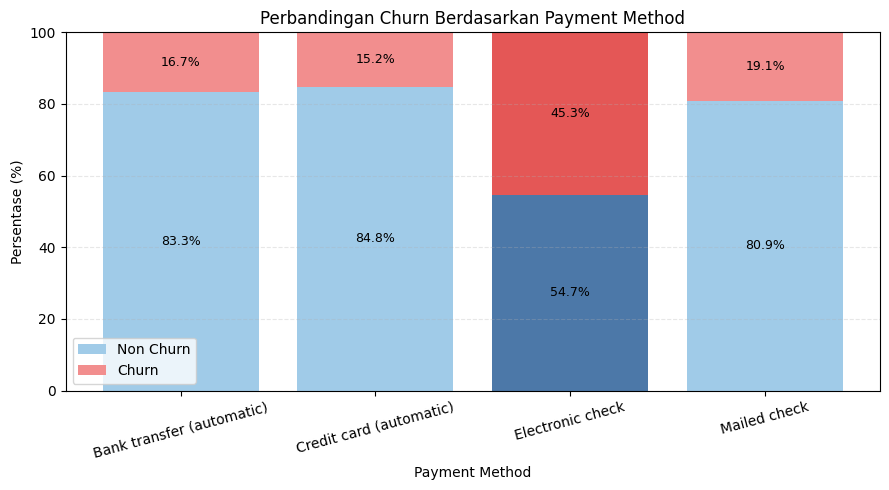

In [20]:
# Crosstab persen
ct_pct = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

# Rename kolom biar jelas
ct_pct.columns = ['Non Churn', 'Churn']

# Cari churn tertinggi
highest_churn = ct_pct['Churn'].idxmax()

# Warna default
non_churn_colors = []
churn_colors = []

for idx in ct_pct.index:
    if idx == highest_churn:
        non_churn_colors.append('#4C78A8')   
        churn_colors.append('#E45756')       
    else:
        non_churn_colors.append('#A0CBE8')   
        churn_colors.append('#F28E8E')       

# Plot
fig, ax = plt.subplots(figsize=(9,5))

# Non churn
ax.bar(
    ct_pct.index,
    ct_pct['Non Churn'],
    color=non_churn_colors,
    label='Non Churn'
)

# Churn
ax.bar(
    ct_pct.index,
    ct_pct['Churn'],
    bottom=ct_pct['Non Churn'],
    color=churn_colors,
    label='Churn'
)

# Tambah label %
for i in range(len(ct_pct)):

    # Non churn label
    ax.text(
        i,
        ct_pct['Non Churn'][i] / 2,
        f"{ct_pct['Non Churn'][i]:.1f}%",
        ha='center',
        va='center',
        fontsize=9
    )

    # Churn label
    ax.text(
        i,
        ct_pct['Non Churn'][i] + (ct_pct['Churn'][i] / 2),
        f"{ct_pct['Churn'][i]:.1f}%",
        ha='center',
        va='center',
        fontsize=9
    )

# Styling
plt.title('Perbandingan Churn Berdasarkan Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Persentase (%)')

plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Insight:
> Metode pembayaran electronic check memiliki jumlah churn yang paling tinggi dibandingkan metode lainnya. Sementara itu, pembayaran otomatis seperti bank transfer dan credit card cenderung memiliki churn yang lebih rendah. Hal ini menunjukkan bahwa metode pembayaran dapat menjadi indikator perilaku pelanggan.

## 4.8 Monthly Charges vs Churn

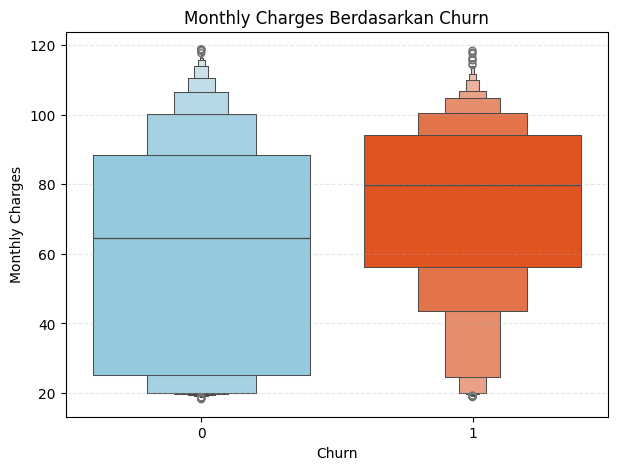

In [21]:
# mengatur ukuran figure agar visualisasi lebih jelas
plt.figure(figsize=(7,5))

# membuat boxenplot untuk melihat distribusi MonthlyCharges berdasarkan status churn
sns.boxenplot(

    # kolom target pada sumbu x
    x='Churn',

    # kolom numerik yang dianalisis pada sumbu y
    y='MonthlyCharges',

    # dataset yang digunakan
    data=df,

    # memberikan warna berbeda pada masing-masing kategori churn
    palette=['skyblue', 'orangered']
)

# menambahkan judul visualisasi
plt.title('Monthly Charges Berdasarkan Churn')

# memberi label pada sumbu x
plt.xlabel('Churn')

# memberi label pada sumbu y
plt.ylabel('Monthly Charges')

# menambahkan garis bantu pada sumbu y agar lebih mudah dibaca
plt.grid(axis='y', linestyle='--', alpha=0.3)

# menampilkan visualisasi
plt.show()

Insight:
> Pelanggan yang melakukan churn cenderung memiliki biaya bulanan yang lebih tinggi dibandingkan yang tidak churn. Hal ini menunjukkan bahwa biaya layanan dapat menjadi salah satu faktor yang mempengaruhi keputusan pelanggan untuk berhenti berlangganan.

## 4.8 Internet Service vs Churn

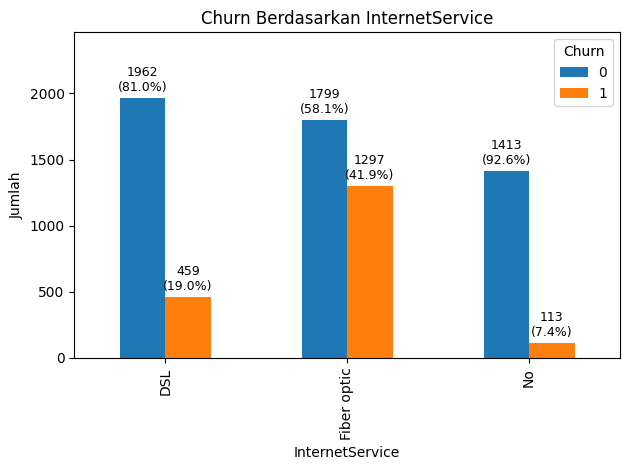

In [22]:
# crosstab
ct = pd.crosstab(df['InternetService'], df['Churn'])
ct_pct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

# plot
ax = ct.plot(kind='bar')

# ambil posisi bar yang asli
for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2

    # cari index untuk ambil persen
    partner_idx = int(p.get_x() + p.get_width() / 2)
    
    # cari label berdasarkan tinggi
    for in_s in ct.index:
        for churn in ct.columns:
            if ct.loc[in_s, churn] == height:
                pct = ct_pct.loc[in_s, churn]
    
    ax.text(x, height + 30, f"{int(height)}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=9)

# label
max_val = ct.values.max()
plt.ylim(0, max_val + 500)
plt.title('Churn Berdasarkan InternetService')
plt.xlabel('InternetService')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

Insight:
> Pelanggan Fiber Optic memiliki churn lebih tinggi dibandingkan DSL. Hal ini sejalan dengan hasil analisis MonthlyCharges yang menunjukkan bahwa pelanggan dengan biaya bulanan lebih tinggi cenderung lebih mudah churn. Kondisi ini mengindikasikan bahwa harga layanan kemungkinan menjadi salah satu faktor utama churn pada pengguna Fiber Optic.

## 4.9 Distribusi Skewness

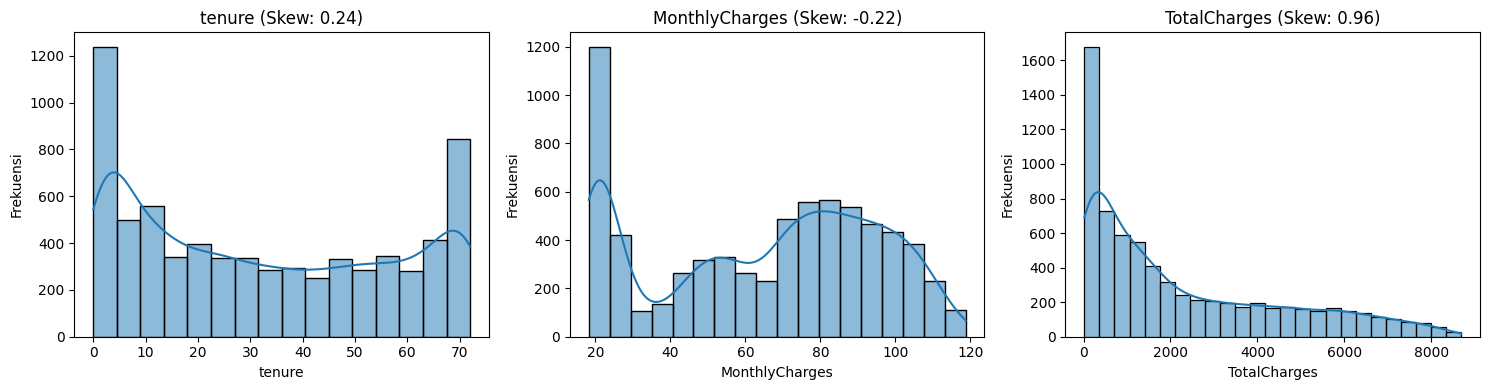

In [23]:
# menentukan kolom numerik yang akan dianalisis distribusinya
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# membuat 1 baris dengan 3 subplot (grafik sejajar ke samping)
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# loop untuk menampilkan setiap kolom dalam subplot
for i, col in enumerate(num_cols):
    
    # membuat histogram untuk melihat distribusi data + kde untuk melihat pola
    sns.histplot(df[col], kde=True, ax=axes[i])
    
    # menghitung nilai skewness untuk mengetahui kemiringan distribusi
    skew_val = df[col].skew()
    
    # menambahkan judul grafik beserta nilai skewness
    axes[i].set_title(f'{col} (Skew: {skew_val:.2f})')
    
    # memberi label pada sumbu x sesuai nama kolom
    axes[i].set_xlabel(col)
    
    # memberi label pada sumbu y (frekuensi data)
    axes[i].set_ylabel('Frekuensi')

# mengatur layout agar tidak saling bertumpuk
plt.tight_layout()

# menampilkan seluruh grafik
plt.show()

Insight:

>- Berdasarkan distribusi data, fitur tenure memiliki distribusi yang relatif seimbang (skew mendekati nol), meskipun terdapat kecenderungan lebih banyak pelanggan pada masa berlangganan awal dan mendekati maksimum.
>
>- Fitur MonthlyCharges juga menunjukkan distribusi yang cukup seimbang dengan sedikit kecenderungan ke kiri (skew negatif), yang berarti sebagian besar pelanggan berada pada rentang biaya menengah hingga tinggi.
>
>- Sementara itu, TotalCharges memiliki distribusi yang cenderung miring ke kanan (skew positif), yang menunjukkan bahwa sebagian besar pelanggan memiliki total biaya yang rendah, namun terdapat beberapa pelanggan dengan total biaya yang sangat tinggi.

## 4.10 Korelasi Fitur Numerik dan Target

In [24]:
# memilih kolom numerik + target untuk analisis korelasi
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

# menghitung korelasi menggunakan metode spearman (untuk hubungan non-linear/monotonik)
corr_spearman = df[num_cols].corr(method='spearman')

# menampilkan hasil korelasi
corr_spearman

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.276417,0.886998,-0.367062
MonthlyCharges,0.276417,1.000000,0.637475,0.184743
TotalCharges,0.886998,0.637475,1.000000,-0.232059
Churn,-0.367062,0.184743,-0.232059,1.000000


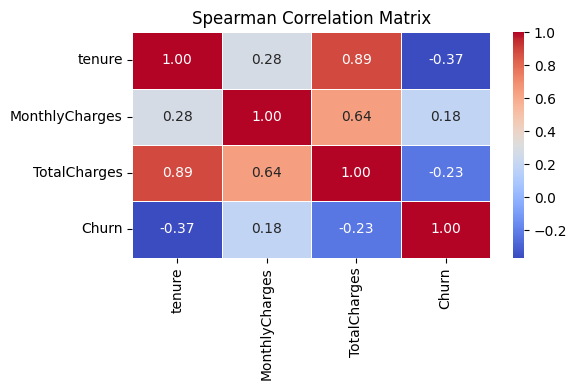

In [25]:
# membuat visualisasi heatmap untuk korelasi spearman
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

# menambahkan judul
plt.title('Spearman Correlation Matrix')

# merapikan layout
plt.tight_layout()

# menampilkan plot
plt.show()

Insight:

>- Berdasarkan korelasi Spearman, fitur tenure memiliki hubungan negatif terhadap Churn (-0.37), yang menunjukkan bahwa semakin lama pelanggan berlangganan, semakin kecil kemungkinan mereka untuk churn.
>
>- Sementara itu, MonthlyCharges memiliki hubungan positif terhadap Churn (0.18), yang mengindikasikan bahwa pelanggan dengan biaya bulanan lebih tinggi cenderung sedikit lebih berisiko untuk berhenti berlangganan.
>
>- Fitur TotalCharges juga menunjukkan hubungan negatif terhadap Churn (-0.23), yang berarti pelanggan dengan total pembayaran lebih tinggi cenderung lebih bertahan.
>
>- Selain itu, terdapat hubungan yang cukup kuat antara tenure dan TotalCharges (0.89), yang menunjukkan bahwa semakin lama pelanggan berlangganan, semakin besar total biaya yang telah dibayarkan.
>
>- Secara keseluruhan, tidak terdapat hubungan yang sangat kuat dengan Churn, sehingga kemungkinan churn dipengaruhi oleh kombinasi beberapa faktor, bukan hanya satu variabel saja.

## 4.11 Cek Outliers

In [26]:
# mendefinisikan kolom numerik
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# loop untuk mengecek outlier menggunakan metode iqr
for col in num_cols:
    
    # menghitung quartile 1 dan quartile 3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # menghitung iqr
    IQR = Q3 - Q1
    
    # menentukan batas bawah dan atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # menghitung jumlah outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


Insight:

> Berdasarkan hasil pengecekan menggunakan metode IQR, tidak ditemukan outlier pada seluruh fitur numerik, yaitu tenure, MonthlyCharges, dan TotalCharges. Hal ini menunjukkan bahwa distribusi data masih berada dalam rentang yang wajar dan tidak terdapat nilai ekstrem yang berpotensi mengganggu proses analisis maupun pemodelan.

# 5. Feature Engineering

## 5.1 Split Data

In [27]:
# memisahkan fitur (x) dan target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

In [28]:
# split data menjadi train dan test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
print(f"Training set  : {X_train.shape}")
print(f"Test set      : {X_test.shape}")
print(f"Churn in train: {y_train.mean():.2%}")
print(f"Churn in test : {y_test.mean():.2%}")

Training set  : (5634, 19)
Test set      : (1409, 19)
Churn in train: 26.55%
Churn in test : 26.47%


## 5.2 Cek Cardinality

In [30]:
# mengecek jumlah kategori unik di setiap kolom kategorikal
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"{col}: {df[col].nunique()}")

gender: 2
Partner: 2
Dependents: 2
PhoneService: 2
MultipleLines: 3
InternetService: 3
OnlineSecurity: 3
OnlineBackup: 3
DeviceProtection: 3
TechSupport: 3
StreamingTV: 3
StreamingMovies: 3
Contract: 3
PaperlessBilling: 2
PaymentMethod: 4


Insight: 

>- Berdasarkan hasil pengecekan cardinality, seluruh fitur kategorikal memiliki jumlah kategori yang relatif kecil, yaitu berkisar antara 2 hingga 4 kategori. Fitur seperti gender, Partner, dan Dependents bersifat biner, sementara fitur lainnya memiliki variasi kategori yang terbatas.
>
>- Hal ini menunjukkan bahwa tidak terdapat fitur dengan cardinality tinggi, sehingga penggunaan OneHotEncoder masih efektif dan tidak akan menyebabkan peningkatan dimensi data yang berlebihan dalam proses pemodelan.

## 5.3 Pisahkan Kolom Numerik & Kategorikal

In [31]:
# mendefinisikan kolom numerik
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# mendefinisikan kolom biner (yes/no)
binary_cols = [
    'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling'
]

# mendefinisikan kolom nominal (tidak memiliki urutan)
nominal_cols = [
    'gender', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaymentMethod'
]

# mendefinisikan kolom ordinal (memiliki urutan)
ordinal_cols = ['Contract']

Insight:

> Fitur kategorikal dibagi menjadi beberapa jenis, yaitu biner, nominal, dan ordinal, untuk memastikan metode encoding yang digunakan sesuai dengan karakteristik data. Hal ini dilakukan agar informasi yang terkandung dalam data dapat dipertahankan dengan lebih baik saat proses pemodelan.

## 5.4 Scaling and Encoding

In [32]:
# Membuat preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('bin', OrdinalEncoder(), binary_cols), # Mengubah Yes/No jadi 0/1 secara otomatis
        ('ord', OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]), ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols)
    ]
)

Insight:

>- StandardScaler digunakan pada fitur numerik untuk menyamakan skala data sehingga setiap fitur memiliki distribusi yang lebih seimbang. Proses ini penting terutama untuk algoritma yang sensitif terhadap perbedaan skala data seperti KNN dan SVM. Tanpa scaling, fitur dengan nilai yang lebih besar dapat lebih mendominasi proses pembelajaran model.
>
>- OrdinalEncoder digunakan pada fitur biner seperti Yes/No agar data kategorikal dapat diubah menjadi bentuk numerik sederhana, yaitu 0 dan 1. Selain itu, OrdinalEncoder juga digunakan pada fitur Contract karena fitur tersebut memiliki urutan tingkatan yang jelas, yaitu Month-to-month, One year, dan Two year. Dengan demikian, model dapat memahami hubungan bertingkat antar kategori tersebut.
>
>- Sementara itu, OneHotEncoder digunakan pada fitur nominal yang tidak memiliki urutan tertentu, seperti metode pembayaran atau jenis layanan internet. Teknik ini mengubah setiap kategori menjadi kolom terpisah agar model tidak menganggap adanya hubungan urutan antar kategori.
>
>- Kombinasi tersebut dilakukan agar setiap fitur dapat direpresentasikan dengan lebih tepat sesuai karakteristik datanya, sehingga model dapat belajar pola data dengan lebih optimal.

# 6. Model Definition

Model yang digunakan pada milestone ini bertujuan untuk memprediksi apakah seorang pelanggan akan melakukan churn atau tidak berdasarkan karakteristik pelanggan, layanan yang digunakan, serta pola pembayaran pelanggan. Karena target yang digunakan terdiri dari dua kelas, yaitu churn dan non-churn, maka pendekatan yang digunakan adalah klasifikasi (classification).

Beberapa algoritma machine learning digunakan untuk dibandingkan performanya sehingga dapat diketahui model yang paling optimal dalam menangani kasus prediksi churn pelanggan.

## 6.1 Algoritma yang Digunakan

1. K-Nearest Neighbors (KNN)

    - KNN merupakan algoritma berbasis jarak yang bekerja dengan melihat kedekatan data baru terhadap data-data sebelumnya. Prediksi kelas ditentukan berdasarkan mayoritas tetangga terdekat.

    - Alasan penggunaan:

        - mudah dipahami dan diimplementasikan,
        - cocok digunakan sebagai baseline model,
        - dapat melihat pola kedekatan antar pelanggan.

    - Hyperparameter utama:

        - n_neighbors = menentukan jumlah tetangga terdekat yang digunakan saat prediksi.

    - Catatan:

        - sensitif terhadap scaling,
        - performa dapat menurun jika jumlah fitur terlalu banyak.


2. Support Vector Machine (SVM)

    - SVM digunakan untuk mencari batas pemisah terbaik (hyperplane) antara pelanggan churn dan non-churn.

    - Alasan penggunaan:

        - efektif untuk klasifikasi dua kelas,
        - mampu menangani pola non-linear menggunakan kernel,
        - cukup baik dalam menangani data dengan dimensi yang banyak.

    - Hyperparameter utama:

        - C = mengatur keseimbangan antara margin dan kesalahan klasifikasi,
        - kernel = menentukan jenis fungsi pemisah,
        - gamma = mengatur pengaruh tiap data pada kernel tertentu.

    - Catatan:

        - sensitif terhadap scaling,
        - dapat menggunakan class_weight='balanced' untuk membantu menangani data imbalance.


3. Decision Tree

    - Decision Tree bekerja dengan membentuk aturan berbasis percabangan untuk menentukan hasil klasifikasi.

    - Alasan penggunaan:

        - mudah dipahami dan diinterpretasikan,
        - dapat menangani data numerik maupun kategorikal,
        - tidak terlalu sensitif terhadap scaling.

    - Hyperparameter utama:

        - max_depth → menentukan kedalaman pohon,
        - min_samples_split → menentukan minimum jumlah data untuk melakukan split.

    - Catatan:

        - rentan mengalami overfitting jika pohon terlalu dalam.


4. Random Forest

    - Random Forest merupakan pengembangan dari Decision Tree dengan metode ensemble menggunakan banyak pohon keputusan.

    - Alasan penggunaan:

        - lebih stabil dibandingkan Decision Tree tunggal,
        - mampu mengurangi overfitting,
        - cukup baik dalam menangani data kompleks.

    - Hyperparameter utama:

        - n_estimators → jumlah pohon yang digunakan,
        - max_depth → kedalaman maksimum tiap pohon.

    - Catatan:

        - performa lebih stabil dibanding Decision Tree,
        - training membutuhkan waktu lebih lama dibanding model tunggal.


5. Gradient Boosting

    - Gradient Boosting merupakan algoritma boosting yang bekerja dengan memperbaiki kesalahan model sebelumnya secara bertahap.

    - Alasan penggunaan:

        - mampu menangkap pola data yang kompleks,
        - sering memberikan performa yang baik pada kasus klasifikasi,
        - efektif untuk meningkatkan performa model secara bertahap.

    - Hyperparameter utama:

        - learning_rate = mengatur kecepatan pembelajaran model,
        - n_estimators = jumlah boosting iteration,
        - max_depth = kedalaman tree pada weak learner.

    - Catatan:

        - lebih kompleks dibanding model sederhana,
        - training cenderung lebih lama,
        - lebih sensitif terhadap tuning parameter.


## 6.2 Penanganan Imbalance

- Berdasarkan hasil EDA, dataset memiliki distribusi kelas yang tidak seimbang, yaitu sekitar 73.5% pelanggan non-churn dan 26.5% pelanggan churn. Kondisi ini berpotensi menyebabkan model lebih fokus memprediksi kelas mayoritas.

- Untuk mengatasi masalah tersebut, digunakan beberapa pendekatan:

    - class_weight='balanced' pada model tertentu,
    - teknik oversampling menggunakan SMOTE pada model boosting,
    - evaluasi model menggunakan metrics yang lebih sesuai untuk data imbalance.

- Tujuan dari proses balancing adalah agar model dapat lebih baik dalam mendeteksi pelanggan churn sebagai kelas minoritas.

## 6.3 Metrics Evaluasi

- Karena dataset bersifat imbalanced, evaluasi model tidak hanya berfokus pada accuracy, tetapi juga menggunakan beberapa metrics lain agar performa model dapat dianalisis secara lebih menyeluruh.

- Metrics yang digunakan antara lain:

    - Accuracy

        Mengukur keseluruhan prediksi model yang benar.

    - Precision

        Mengukur seberapa tepat model saat memprediksi pelanggan churn.

    - Recall

        Mengukur kemampuan model dalam mendeteksi pelanggan yang benar-benar churn.

    - F1-score

        Mengukur keseimbangan antara precision dan recall.

    - ROC-AUC

        Mengukur kemampuan model dalam membedakan kelas churn dan non-churn pada berbagai threshold prediksi.

- Pada milestone ini, fokus utama evaluasi diarahkan pada Recall dan F1-score, karena dalam kasus churn prediction lebih penting untuk mendeteksi pelanggan yang berpotensi churn dibandingkan hanya memperoleh accuracy yang tinggi.

# 7. Model Training

## 7.1 Training Baseline Model

In [33]:
# membuat pipeline baseline
models = {

    # KNN
    'KNN': Pipeline([
        ('prep', preprocessor),
        ('model', KNeighborsClassifier())
    ]),

    # SVM
    'SVM': Pipeline([
        ('prep', preprocessor),
        ('model', SVC(probability=True))
    ]),

    # Decision Tree
    'Decision Tree': Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42
        ))
    ]),

    # Random Forest
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            random_state=42
        ))
    ]),

    # Gradient Boosting
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

In [34]:
# menyimpan hasil prediksi baseline
predictions = {}

# loop training seluruh model baseline
for name, model in models.items():

    # training model
    model.fit(X_train, y_train)

    # prediksi data test
    y_pred = model.predict(X_test)

    # simpan hasil prediksi
    predictions[name] = y_pred

## 7.2 Cross Validation

In [35]:
# menyimpan hasil cross validation
cv_results = {}

# cross validation seluruh model baseline
for name, model in models.items():

    # cross validation menggunakan f1-score
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1'
    )

    # simpan hasil
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std()
    }

    # tampilkan hasil
    print(f"{name}")
    print(f"Mean F1: {scores.mean():.4f}")
    print(f"Std    : {scores.std():.4f}\n")

KNN
Mean F1: 0.5347
Std    : 0.0185

SVM
Mean F1: 0.5518
Std    : 0.0215

Decision Tree
Mean F1: 0.4902
Std    : 0.0166

Random Forest
Mean F1: 0.5361
Std    : 0.0196

Gradient Boosting
Mean F1: 0.5755
Std    : 0.0245



Insight:

>- Berdasarkan hasil cross validation, model Gradient Boosting menunjukkan performa terbaik dibandingkan model lainnya dengan Mean F1-score sebesar 0.5755. Selain memiliki performa tertinggi, model ini juga menunjukkan tingkat konsistensi yang cukup baik dengan standar deviasi sebesar 0.0245, sehingga performanya cenderung stabil pada berbagai pembagian data.
>
>- Model SVM juga menunjukkan performa yang cukup baik dengan Mean F1-score sebesar 0.5518 dan standar deviasi sebesar 0.0215. Hasil tersebut menunjukkan bahwa SVM mampu memberikan performa yang cukup konsisten dan kompetitif dalam menangani kasus churn prediction.
>
>- Sementara itu, model Random Forest, dan KNN masih menunjukkan performa yang cukup baik, namun belum mampu melampaui performa Gradient Boosting maupun SVM. Di sisi lain, Decision Tree memiliki performa paling rendah dibandingkan model lainnya dengan Mean F1-score sebesar 0.4902.
>
>- Berdasarkan hasil tersebut, model Gradient Boosting dan SVM dipilih sebagai kandidat utama untuk tahap pengembangan selanjutnya karena keduanya memiliki performa yang paling baik dibandingkan model lain. Namun, Gradient Boosting terlihat lebih unggul karena memiliki Mean F1-score tertinggi sehingga berpotensi memberikan performa yang lebih optimal pada tahap tuning dan evaluasi lanjutan.

## 7.3 Best Model

In [36]:
# mengurutkan model berdasarkan mean f1-score
sorted_models = sorted(
    cv_results.items(),
    key=lambda x: x[1]['mean'],
    reverse=True
)

# mengambil 2 kandidat terbaik
top_2_models = sorted_models[:2]

# tampilkan kandidat terbaik
print("Top 2 Candidate Models:\n")

for name, score in top_2_models:
    print(f"{name}")
    print(f"Mean F1  : {score['mean']:.4f}")
    print(f"Std      : {score['std']:.4f}\n")

Top 2 Candidate Models:

Gradient Boosting
Mean F1  : 0.5755
Std      : 0.0245

SVM
Mean F1  : 0.5518
Std      : 0.0215



## 7.4 Training Model with Balancing 

In [37]:
# menghitung rasio imbalance
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# pipeline balanced
models_bal = {

    # SVM Balanced
    'SVM Balanced': Pipeline([
        ('prep', preprocessor),
        ('model', SVC(
            class_weight='balanced',
            probability=True
        ))
    ]),

    # Decision Tree Balanced
    'Decision Tree Balanced': Pipeline([
        ('prep', preprocessor),
        ('model', DecisionTreeClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ]),

    # Random Forest Balanced
    'Random Forest Balanced': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ]),

    # Gradient Boosting + SMOTE
    'Gradient Boosting SMOTE': ImbPipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

In [38]:
# menyimpan hasil prediksi balanced
predictions_bal = {}

# training seluruh model balanced
for name, model in models_bal.items():

    # training model
    model.fit(X_train, y_train)

    # prediksi data test
    y_pred = model.predict(X_test)

    # simpan hasil prediksi
    predictions_bal[name] = y_pred

## 7.5 Hyperparameter Tuning

### 7.5.1 Gradient Boosting Balanced Tuning

In [39]:
# pipeline gradient boosting + smote
pipe_gb_smote = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

# parameter tuning
param_grid_gb = {

    # jumlah estimator
    'model__n_estimators': [100, 200],

    # learning rate
    'model__learning_rate': [0.01, 0.1],

    # kedalaman tree
    'model__max_depth': [3, 5],

    # minimum split
    'model__min_samples_split': [2, 5]
}

# grid search
grid_gb = GridSearchCV(
    estimator=pipe_gb_smote,
    param_grid=param_grid_gb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# training tuning
grid_gb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('bin',
                                                                         OrdinalEncoder(),
                                                                         ['Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'PaperlessBilling']),
                                                                        ('ord',
                                                                         OrdinalEncoder(categories=[['Month-to-month',
                                                                                                     'One '
                                                                                                     'year',
                                                                                                     'Two '
                                                                                                     'year']]),
                                                                         ['Contract']),
                                                                        ('nom',
                                                                         OneHotEncoder(...
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'PaymentMethod'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

### 7.5.2 SVM Balanced Tuning

In [40]:
# pipeline svm balanced
pipe_svm_bal = Pipeline([
    ('prep', preprocessor),
    ('model', SVC(
        class_weight='balanced',
        probability=True
    ))
])

# parameter svm
param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

# grid search svm
grid_svm_bal = GridSearchCV(
    estimator=pipe_svm_bal,
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# training tuning
grid_svm_bal.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('bin',
                                                                         OrdinalEncoder(),
                                                                         ['Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'PaperlessBilling']),
                                                                        ('ord',
                                                                         OrdinalEncoder(categories=[['Month-to-month',
                                                                                                     'One '
                                                                                                     'year',
                                                                                                     'Two '
                                                                                                     'year']]),
                                                                         ['Contract']),
                                                                        ('nom',
                                                                         OneHotEncoder(...
                                                                                       sparse_output=False),
                                                                         ['gender',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        SVC(class_weight='balanced',
                                            probability=True))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['rbf', 'linear']},
             scoring='f1')

## 7.6 Best Model and Predict

In [41]:
# model svm terbaik
best_svm_bal = grid_svm_bal.best_estimator_

# prediksi svm tuned
y_pred_svm_bal_tuned = best_svm_bal.predict(X_test)

# model terbaik
best_gb = grid_gb.best_estimator_

# prediksi
y_pred_gb_tuned = best_gb.predict(X_test)

# 8. Model Evaluation

## 8.1 Evaluasi Model Baseline

Pada tahap ini dilakukan evaluasi terhadap seluruh model baseline untuk melihat performa awal masing-masing algoritma dalam memprediksi churn.

In [42]:
# evaluasi seluruh model baseline
for name, y_pred in predictions.items():

    print(f"=============== {name} ===============")
    print(classification_report(y_test, y_pred))

=============== KNN ===============
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1036
           1       0.58      0.52      0.55       373

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.77      0.77      1409

=============== SVM ===============
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.52      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

=============== Decision Tree ===============
              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1036
           1       0.47      0.51      0.49       373

    accuracy                           0.72      1409
   macro a

Insight:

>- Berdasarkan hasil evaluasi model baseline, setiap algoritma menunjukkan performa yang cukup baik dalam mengklasifikasikan pelanggan non-churn (kelas 0), namun masih mengalami kesulitan dalam mendeteksi pelanggan churn (kelas 1). Hal ini terlihat dari nilai recall pada kelas churn yang masih relatif rendah di seluruh model.
>
>- Model Gradient Boosting menunjukkan performa terbaik secara keseluruhan dengan accuracy sebesar 0.79 dan F1-score churn sebesar 0.56. Selain itu, model juga memiliki keseimbangan performa yang cukup baik antara precision dan recall dibandingkan model lainnya.
>
>- Model SVM memiliki accuracy yang sama tinggi dengan Gradient Boosting, namun recall pada kelas churn masih lebih rendah, yang menunjukkan bahwa model cenderung lebih fokus pada kelas mayoritas. Sementara itu, KNN dan Random Forest menunjukkan performa yang cukup stabil tetapi kemampuan mendeteksi churn masih terbatas.
>
>- Di sisi lain, Decision Tree memiliki performa paling rendah dengan nilai F1-score churn sebesar 0.49, yang menunjukkan bahwa model kurang optimal dalam menangkap pola pada data churn pelanggan.
>
>- Secara keseluruhan, hasil baseline menunjukkan bahwa permasalahan utama pada dataset terletak pada ketidakseimbangan kelas, sehingga diperlukan penanganan imbalance dan tuning lebih lanjut untuk meningkatkan kemampuan model dalam mendeteksi pelanggan churn

## 8.2 Cross Validation Evaluation

In [43]:
# menampilkan hasil cross validation
cv_df = pd.DataFrame(cv_results).T

# ubah nama kolom
cv_df.columns = ['Mean F1 Score', 'Std']

# tampilkan hasil
cv_df

,Mean F1 Score,Std
KNN,0.534745,0.018545
SVM,0.551825,0.021547
Decision Tree,0.490224,0.016638
Random Forest,0.536078,0.019553
Gradient Boosting,0.575509,0.024520


Insight:

>- Berdasarkan hasil cross validation, model Gradient Boosting memperoleh performa terbaik dengan nilai Mean F1 Score sebesar 0.5928 dan standar deviasi paling kecil yaitu 0.0168. Hal ini menunjukkan bahwa model tidak hanya memiliki performa yang baik, tetapi juga stabil pada berbagai pembagian data selama proses validasi.
>
>- Model SVM berada pada posisi kedua dengan Mean F1 Score sebesar 0.5741 dan nilai standar deviasi yang cukup kecil, sehingga menunjukkan performa yang konsisten. Sementara itu, Random Forest juga memberikan hasil yang cukup baik meskipun performanya masih berada di bawah Gradient Boosting dan SVM.
>
>- Di sisi lain, Decision Tree memiliki performa paling rendah dengan Mean F1 Score sebesar 0.4970. Hal ini menunjukkan bahwa model kurang mampu menangkap pola pada data churn pelanggan dibandingkan model lainnya.
>
>- Secara keseluruhan, hasil cross validation menunjukkan bahwa model berbasis boosting memiliki performa yang lebih baik dalam menangani kasus churn prediction pada dataset ini. Oleh karena itu, Gradient Boosting dipilih sebagai kandidat model terbaik untuk tahap pengembangan selanjutnya, seperti balancing dan hyperparameter tuning.

## 8.3 Balanced Model Evaluation

In [44]:
# evaluasi model balanced
for name, y_pred in predictions_bal.items():

    print(f"=============== {name} ===============")
    print(classification_report(y_test, y_pred))

=============== SVM Balanced ===============
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.81      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

=============== Decision Tree Balanced ===============
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1036
           1       0.48      0.49      0.49       373

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409

=============== Random Forest Balanced ===============
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.45      0.53       373

    accuracy               

Insight:

>- Berdasarkan hasil evaluasi setelah dilakukan penanganan imbalance, performa model dalam mendeteksi pelanggan churn mengalami peningkatan dibandingkan model baseline, terutama pada nilai recall kelas churn. Hal ini menunjukkan bahwa balancing membantu model menjadi lebih sensitif terhadap kelas minoritas.
>
>- Model SVM Balanced menunjukkan peningkatan recall churn yang sangat signifikan hingga mencapai 0.78, yang berarti model mampu mendeteksi sebagian besar pelanggan yang berpotensi churn. Namun, peningkatan tersebut diikuti dengan penurunan recall pada kelas non-churn dan accuracy secara keseluruhan, sehingga model menjadi lebih agresif dalam memprediksi churn.
>
>- Model Gradient Boosting memberikan performa yang paling seimbang dibandingkan model balanced lainnya. Model berhasil mempertahankan accuracy sebesar 0.77 dengan recall churn sebesar 0.68 dan F1-score churn sebesar 0.61. Selain itu, performa pada kelas non-churn juga tetap cukup baik, sehingga model mampu memberikan keseimbangan performa antara kedua kelas. Di sisi lain, Decision Tree Balanced dan Random Forest Balanced tidak menunjukkan peningkatan yang terlalu signifikan dibandingkan model baseline.
>
>- Secara keseluruhan, hasil evaluasi menunjukkan bahwa penanganan imbalance memberikan dampak positif terhadap kemampuan model dalam mendeteksi pelanggan churn. Dari seluruh model balanced yang diuji, Gradient Boosting SMOTE menjadi model dengan performa paling seimbang dan stabil untuk digunakan pada kasus churn prediction.

## 8.4 Hyperparameter Tuning Evaluation

In [45]:
# hasil tuning svm
print("=== SVM Balanced Tuning ===")
print("Best Params :", grid_svm_bal.best_params_)
print("Best Score  :", grid_svm_bal.best_score_)

# hasil tuning gradient boosting
print("\n=== Gradient Boosting Tuning ===")
print("Best Params :", grid_gb.best_params_)
print("Best Score  :", grid_gb.best_score_)

=== SVM Balanced Tuning ===
Best Params : {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Score  : 0.616910647231491

=== Gradient Boosting Tuning ===
Best Params : {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best Score  : 0.6293692054115366


Insight:

>- Berdasarkan hasil hyperparameter tuning, model Gradient Boosting memperoleh performa terbaik dengan nilai cross validation score sebesar 0.6294, lebih tinggi dibandingkan SVM Balanced yang memperoleh nilai sebesar 0.6169. Hal ini menunjukkan bahwa proses tuning berhasil meningkatkan performa model dibandingkan penggunaan parameter default sebelumnya.
>
>- Pada model SVM Balanced, kombinasi parameter terbaik diperoleh pada nilai C = 1, gamma = scale, dan kernel = rbf. Parameter tersebut menunjukkan bahwa model bekerja optimal dengan kernel non-linear sehingga mampu menangkap pola data churn dengan lebih baik.
>
>- Sementara itu, pada model Gradient Boosting, parameter terbaik diperoleh pada learning_rate = 0.01, max_depth = 5, min_samples_split = 5, dan n_estimators = 200. Kombinasi ini menunjukkan bahwa model bekerja lebih optimal dengan proses pembelajaran yang lebih bertahap serta jumlah estimator yang lebih banyak, sehingga model mampu mempelajari pola data secara lebih mendalam tanpa menyebabkan overfitting yang signifikan.
>
>- Secara keseluruhan, hasil tuning menunjukkan bahwa model Gradient Boosting  memiliki performa yang lebih baik dan lebih stabil dibandingkan model lainnya, sehingga dipilih sebagai kandidat model terbaik untuk tahap evaluasi akhir.

## 8.5 Classification Report Comparison

In [46]:
# evaluasi svm tuned
print(20*'=', "SVM Tuned", 20*'=')
print(classification_report(y_test, y_pred_svm_bal_tuned))

# evaluasi gradient boosting smote tuned
print("\n", 15*'=', "Gradient Boosting Tuned", 15*'=')
print(classification_report(y_test, y_pred_gb_tuned))

==================== SVM Tuned ====================
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.81      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409


 =============== Gradient Boosting Tuned ===============
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1036
           1       0.56      0.77      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.78      0.79      1409



Insight:

>* Berdasarkan hasil evaluasi akhir setelah dilakukan hyperparameter tuning, model SVM Tuned dan Gradient Boosting Tuned sama-sama menunjukkan performa yang cukup baik dalam mendeteksi pelanggan churn. Kedua model berhasil meningkatkan kemampuan deteksi churn dibandingkan model baseline sebelumnya.
>
>* Model SVM Tuned memiliki recall churn tertinggi, yaitu sebesar 0.81. Hal ini menunjukkan bahwa model sangat baik dalam mendeteksi pelanggan yang berpotensi churn sehingga risiko pelanggan churn yang tidak terdeteksi menjadi lebih kecil. Namun, model juga menghasilkan prediksi churn yang lebih agresif, sehingga jumlah false positive menjadi cukup tinggi. Kondisi ini dapat menyebabkan perusahaan memberikan program retensi kepada banyak pelanggan yang sebenarnya tidak berpotensi churn.
>
>* Sementara itu, model Gradient Boosting Tuned memberikan performa yang lebih seimbang antara kelas churn dan non-churn. Model memperoleh accuracy sebesar 0.78, recall churn sebesar 0.77, dan F1-score churn sebesar 0.65. Meskipun recall churn sedikit lebih rendah dibandingkan SVM Tuned, model masih mampu mendeteksi sebagian besar pelanggan churn dengan baik.
>
>* Selain itu, model Gradient Boosting Tuned memiliki performa yang lebih stabil pada kedua kelas. Model mampu mempertahankan recall non-churn yang lebih baik sehingga jumlah false positive dapat ditekan dibandingkan model SVM. Hal ini penting dalam konteks bisnis karena perusahaan tidak hanya perlu mendeteksi pelanggan churn, tetapi juga perlu menjaga agar strategi retensi tetap efisien dan tepat sasaran.
>
>* Dari sisi bisnis, biaya memberikan promo atau program retensi kepada pelanggan yang sebenarnya tidak churn memang masih lebih baik dibandingkan kehilangan pelanggan. Namun, apabila false positive terlalu tinggi, perusahaan dapat mengeluarkan biaya retensi yang berlebihan dan kurang efektif. Oleh karena itu, diperlukan model yang mampu menjaga keseimbangan antara mendeteksi churn dan mengontrol kesalahan prediksi.
>
>* Secara keseluruhan, model Gradient Boosting Tuned dipilih sebagai model terbaik karena mampu memberikan keseimbangan performa yang lebih baik dan lebih stabil secara keseluruhan. Model tetap memiliki kemampuan deteksi churn yang tinggi, namun dengan distribusi prediksi yang lebih seimbang sehingga lebih sesuai untuk digunakan dalam strategi retensi pelanggan pada industri telekomunikasi.

## 8.6 Baseline vs Tuned Comparison

In [47]:
# function untuk mengambil metrics evaluasi pada kelas churn (kelas 1)
def get_metrics(y_true, y_pred):

    # membuat classification report dalam bentuk dictionary
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    # mengambil metrics yang dibutuhkan
    return {
        'Accuracy': round(report['accuracy'], 2),
        'Precision Churn': round(report['1']['precision'], 2),
        'Recall Churn': round(report['1']['recall'], 2),
        'F1-Score Churn': round(report['1']['f1-score'], 2)
    }

# mengambil hasil prediksi model baseline SVM
y_pred_svm_base = predictions['SVM']

# mengambil hasil prediksi model baseline Gradient Boosting
y_pred_gb_base = predictions['Gradient Boosting']

# membuat tabel perbandingan metrics baseline dan tuned model
comparison_results = pd.DataFrame({

    # metrics SVM baseline
    'SVM Baseline': get_metrics(y_test, y_pred_svm_base),

    # metrics SVM tuned
    'SVM Tuned': get_metrics(y_test, y_pred_svm_bal_tuned),

    # metrics Gradient Boosting baseline
    'Gradient Boosting Baseline': get_metrics(y_test, y_pred_gb_base),

    # metrics Gradient Boosting tuned
    'Gradient Boosting Tuned': get_metrics(y_test, y_pred_gb_tuned)

}).T

# menampilkan tabel comparison
comparison_results

,Accuracy,Precision Churn,Recall Churn,F1-Score Churn
SVM Baseline,0.81,0.70,0.52,0.60
SVM Tuned,0.76,0.53,0.81,0.64
Gradient Boosting Baseline,0.81,0.67,0.54,0.60
Gradient Boosting Tuned,0.78,0.56,0.77,0.65


Insight:

>- Berdasarkan hasil perbandingan antara model baseline dan model setelah tuning, proses hyperparameter tuning memberikan perubahan performa yang cukup signifikan pada kedua model, terutama dalam meningkatkan kemampuan deteksi pelanggan churn.
>
>- Pada model SVM, tuning berhasil meningkatkan recall churn dari 0.52 menjadi 0.81 serta meningkatkan F1-score churn dari 0.60 menjadi 0.64. Hal ini menunjukkan bahwa model menjadi jauh lebih baik dalam mendeteksi pelanggan yang berpotensi churn. Namun, peningkatan recall tersebut diikuti dengan penurunan precision churn dari 0.70 menjadi 0.53 serta penurunan accuracy dari 0.81 menjadi 0.76. Kondisi ini menunjukkan bahwa model menjadi lebih agresif dalam memprediksi churn sehingga menghasilkan false positive yang lebih tinggi.
>
>- Sementara itu, model Gradient Boosting juga mengalami peningkatan performa setelah tuning. Recall churn meningkat dari 0.54 menjadi 0.77 dan F1-score churn meningkat dari 0.60 menjadi 0.65. Meskipun accuracy sedikit menurun dari 0.81 menjadi 0.78 dan precision churn turun dari 0.67 menjadi 0.56, model masih mampu menjaga keseimbangan performa dengan lebih baik dibandingkan SVM Tuned.
>
>- Secara keseluruhan, hasil tuning menunjukkan bahwa kedua model menjadi lebih baik dalam mendeteksi pelanggan churn dibandingkan model baseline sebelumnya. Hal ini penting dalam konteks bisnis churn prediction karena perusahaan lebih membutuhkan model yang mampu mendeteksi pelanggan yang berpotensi churn meskipun terdapat peningkatan false positive.
>
>- Di antara kedua model tersebut, Gradient Boosting Tuned dipilih sebagai model terbaik karena mampu memberikan keseimbangan performa yang lebih baik antara recall churn, precision, dan accuracy sehingga hasil prediksi menjadi lebih stabil untuk digunakan dalam strategi retensi pelanggan.

## 8.7 Confusion Matrix Comparison

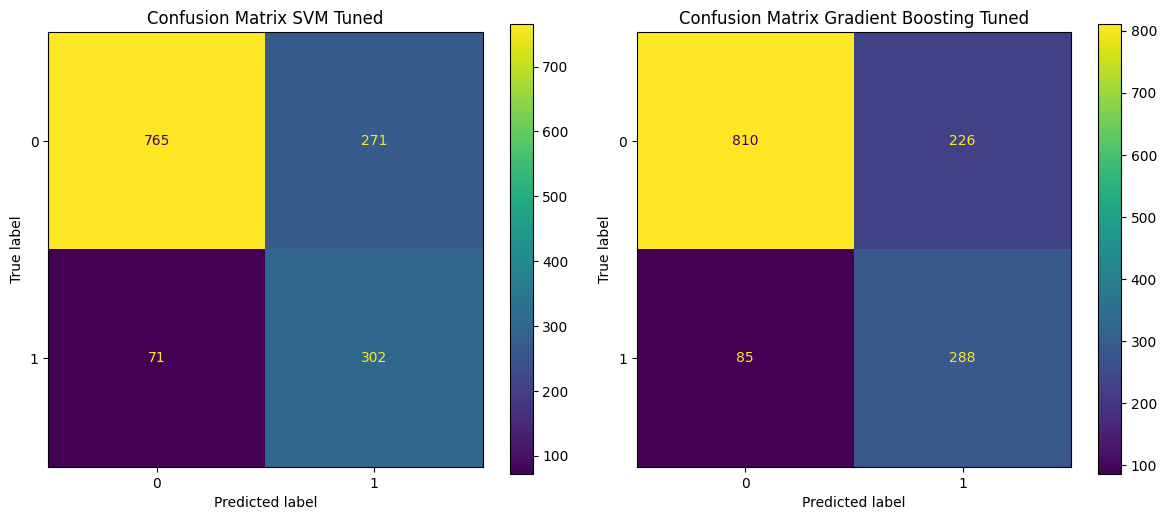

In [48]:
# membuat figure dengan 1 baris 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# confusion matrix svm
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_bal_tuned,
    ax=axes[0]
)

axes[0].set_title('Confusion Matrix SVM Tuned')

# confusion matrix gradient boosting
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb_tuned,
    ax=axes[1]
)

axes[1].set_title('Confusion Matrix Gradient Boosting Tuned')

# merapikan layout
plt.tight_layout()

# tampilkan plot
plt.show()

Insight:

>- Berdasarkan hasil confusion matrix, model SVM Tuned berhasil mendeteksi pelanggan churn dengan cukup baik, ditunjukkan oleh jumlah True Positive sebanyak 302 data. Selain itu, jumlah False Negative hanya sebanyak 71 data, yang menunjukkan bahwa sebagian besar pelanggan churn berhasil terdeteksi oleh model. Hal ini sejalan dengan nilai recall churn yang cukup tinggi pada model SVM.
>
>- Namun, model SVM Tuned juga menghasilkan False Positive yang cukup besar, yaitu sebanyak 271 data. Artinya, terdapat cukup banyak pelanggan non-churn yang diprediksi sebagai churn. Dalam konteks bisnis, kondisi ini dapat menyebabkan perusahaan memberikan program retensi atau promosi kepada pelanggan yang sebenarnya tidak berpotensi churn.
>
>- Sementara itu, model Gradient Boosting Tuned menunjukkan distribusi prediksi yang lebih seimbang. Model berhasil meningkatkan jumlah True Negative menjadi 810 data dan menurunkan jumlah False Positive menjadi 226 data dibandingkan SVM Tuned. Hal ini menunjukkan bahwa model lebih baik dalam mempertahankan prediksi pelanggan non-churn.
>
>- Meskipun jumlah True Positive pada Gradient Boosting Tuned sedikit lebih rendah, yaitu sebanyak 288 data, model masih mampu mendeteksi pelanggan churn dengan cukup baik. Selain itu, jumlah False Negative yang dihasilkan juga masih relatif rendah, yaitu sebanyak 85 data.
>
>- Secara keseluruhan, confusion matrix menunjukkan bahwa Gradient Boosting Tuned memiliki keseimbangan performa yang lebih baik antara mendeteksi pelanggan churn dan mengurangi kesalahan prediksi pada pelanggan non-churn. Oleh karena itu, model ini dipilih sebagai model terbaik karena memberikan performa yang lebih stabil dan lebih seimbang untuk kasus churn prediction.

## 8.8 ROC AUC Comparison

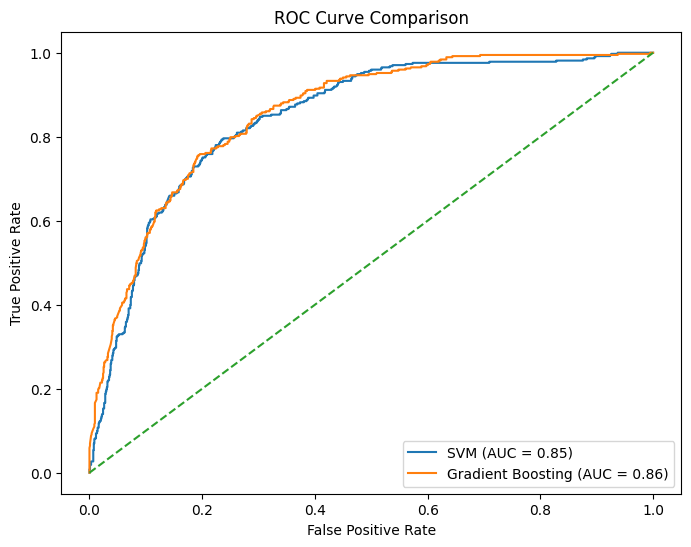

In [49]:
# probabilitas churn svm
y_prob_svm = best_svm_bal.predict_proba(X_test)[:,1]

# probabilitas churn gradient boosting
y_prob_gb = best_gb.predict_proba(X_test)[:,1]

# hitung roc curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# auc score
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_gb = roc_auc_score(y_test, y_prob_gb)

# plot roc curve
plt.figure(figsize=(8,6))

plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.2f})')

# garis random
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()
plt.show()

Insight:

>- Berdasarkan hasil ROC Curve, kedua model menunjukkan kemampuan klasifikasi yang baik dalam membedakan pelanggan churn dan non-churn karena memiliki nilai AUC di atas 0.80. Nilai AUC yang mendekati 1 menunjukkan bahwa model memiliki kemampuan yang baik dalam melakukan klasifikasi pada berbagai threshold prediksi.
>
>- Model Gradient Boosting memperoleh nilai AUC sebesar 0.86, sedikit lebih tinggi dibandingkan model SVM  dengan nilai AUC sebesar 0.85. Hal ini menunjukkan bahwa Gradient Boosting  memiliki kemampuan yang lebih baik dan lebih konsisten dalam membedakan pelanggan churn dan non-churn secara keseluruhan.
>
>- Selain itu, kurva ROC Gradient Boosting terlihat lebih stabil dan cenderung berada di atas kurva SVM pada sebagian besar threshold, yang menunjukkan performa klasifikasi yang lebih optimal.
>
>- Secara keseluruhan, hasil ROC-AUC memperkuat hasil evaluasi sebelumnya bahwa model Gradient Boosting merupakan model terbaik karena mampu memberikan performa klasifikasi yang lebih baik dan lebih seimbang dibandingkan model lainnya.

## 8.9 Analisis Fit Best Model

In [50]:
# train score gradient boosting 
train_score = best_gb.score(X_train, y_train)

# test score
test_score = best_gb.score(X_test, y_test)

print("Train Score :", train_score)
print("Test Score  :", test_score)

Train Score : 0.7866524671636492
Test Score  : 0.7792760823278921


Insight:

>- Berdasarkan hasil evaluasi, model Gradient Boosting memperoleh train score sebesar 0.7867 dan test score sebesar 0.7793. Selisih antara kedua nilai tersebut relatif kecil, sehingga menunjukkan bahwa performa model pada data training dan data testing cukup konsisten.
>
>- Hasil tersebut menunjukkan bahwa model tidak hanya mempelajari pola pada data training, tetapi juga mampu memberikan performa yang baik saat diuji pada data baru. Selain itu, selisih train score dan test score yang tidak terlalu jauh mengindikasikan bahwa model tidak mengalami overfitting yang signifikan.
>
>- Dengan demikian, model dapat dikategorikan dalam kondisi good fit karena mampu menjaga keseimbangan performa antara data training dan data testing dengan cukup baik. Model juga menunjukkan kestabilan yang baik untuk digunakan pada kasus prediksi churn pelanggan.

## 8.10 Feature Importance

In [51]:
# ambil model gradient boosting
gb_model = best_gb.named_steps['model']

# ambil nama fitur setelah preprocessing
feature_names = preprocessor.get_feature_names_out()

# feature importance
importance = gb_model.feature_importances_

# dataframe
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# urutkan
feat_imp = feat_imp.sort_values(
    by='Importance',
    ascending=False
)

# tampilkan top 10
feat_imp.head(10)

,Feature,Importance
7,ord__Contract,0.537932
16,nom__OnlineSecurity_No,0.087536
0,num__tenure,0.078024
1,num__MonthlyCharges,0.060995
36,nom__PaymentMethod_Electronic check,0.056574
6,bin__PaperlessBilling,0.034548
25,nom__TechSupport_No,0.030285
4,bin__Dependents,0.021117
14,nom__InternetService_Fiber optic,0.017244
33,nom__StreamingMovies_Yes,0.015395


Insight:

> * Berdasarkan hasil feature importance, fitur Contract menjadi faktor yang paling berpengaruh dalam prediksi churn pelanggan dengan nilai importance sebesar 0.5379. Nilai tersebut jauh lebih tinggi dibandingkan fitur lainnya, sehingga dapat dilihat bahwa jenis kontrak memiliki hubungan yang sangat kuat terhadap kemungkinan pelanggan melakukan churn.
>
> * Dominasi fitur Contract menunjukkan bahwa tingkat komitmen pelanggan menjadi faktor penting dalam mempertahankan pelanggan. Pelanggan dengan kontrak jangka panjang cenderung lebih loyal dibandingkan pelanggan dengan kontrak bulanan (*month-to-month*). Selain itu, perbedaan nilai importance yang cukup jauh dibanding fitur lain menunjukkan bahwa jenis kontrak menjadi faktor utama dalam menentukan kemungkinan pelanggan bertahan atau berhenti berlangganan.
>
> * Faktor kedua yang paling berpengaruh adalah OnlineSecurity_No dengan nilai importance sebesar 0.0875. Hal ini menunjukkan bahwa pelanggan yang tidak menggunakan layanan tambahan seperti Online Security cenderung lebih mudah berpindah ke layanan lain dibandingkan pelanggan yang menggunakan layanan tersebut.
>
> * Selanjutnya, fitur tenure dengan nilai importance sebesar 0.0780 juga memiliki pengaruh yang cukup besar terhadap prediksi churn. Semakin lama pelanggan menggunakan layanan, kemungkinan pelanggan untuk tetap bertahan juga cenderung lebih tinggi.
>
> * Fitur MonthlyCharges berada pada posisi berikutnya dengan nilai importance sebesar 0.0610. Hal ini menunjukkan bahwa biaya bulanan juga memengaruhi keputusan pelanggan untuk tetap menggunakan layanan atau berhenti berlangganan. Pelanggan dengan biaya bulanan yang lebih tinggi terlihat memiliki risiko churn yang lebih besar.
>
> * Selain itu, metode pembayaran Electronic check dengan nilai importance sebesar 0.0566 juga memberikan pengaruh terhadap churn pelanggan. Pelanggan yang menggunakan metode pembayaran tersebut terlihat lebih sering melakukan churn dibandingkan metode pembayaran lainnya.
>
> * Beberapa fitur lain seperti PaperlessBilling, TechSupport_No, Dependents, InternetService_Fiber optic, dan StreamingMovies_Yes juga ikut memberikan pengaruh terhadap prediksi churn meskipun nilainya tidak sebesar fitur utama sebelumnya. Hal ini menunjukkan bahwa pola penggunaan layanan dan kebutuhan pelanggan juga ikut memengaruhi kemungkinan churn.
>
> * Pada fitur kategorikal yang menggunakan OneHotEncoder, setiap kategori dipisahkan menjadi fitur tersendiri sehingga nilai importance ditampilkan dalam bentuk kategori individual.
>
> * Secara keseluruhan, hasil feature importance menunjukkan bahwa faktor kontrak pelanggan, layanan tambahan, lama berlangganan, biaya layanan, dan metode pembayaran menjadi faktor utama yang memengaruhi churn pelanggan. Insight ini dapat membantu perusahaan menentukan strategi retensi pelanggan yang lebih tepat sasaran.


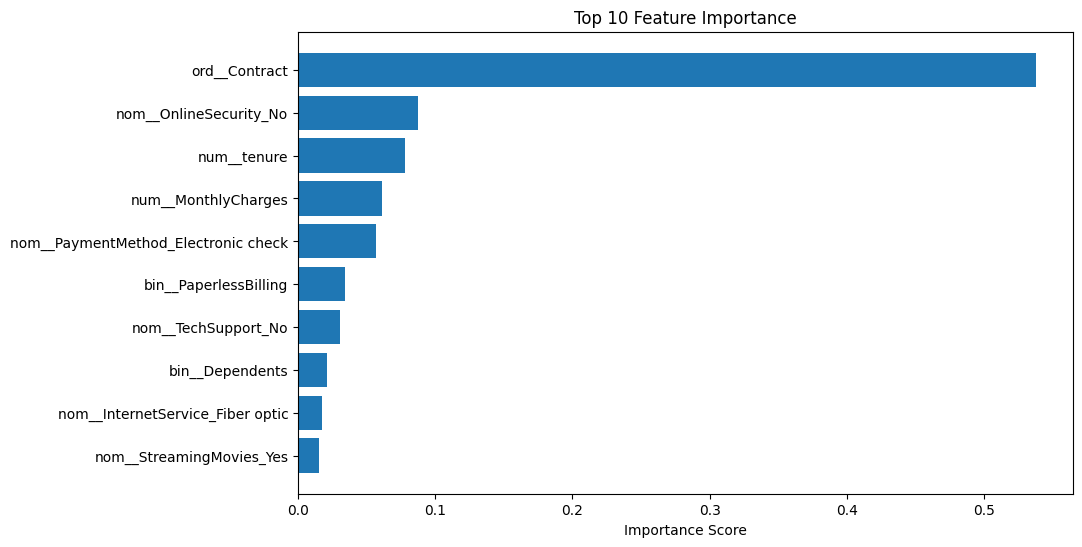

In [52]:
# mengatur ukuran figure
plt.figure(figsize=(10,6))

# membuat horizontal bar chart untuk top 10 feature importance
plt.barh(

    # nama fitur
    feat_imp['Feature'].head(10),

    # nilai importance fitur
    feat_imp['Importance'].head(10)
)

# membalik urutan sumbu y agar feature paling penting berada di atas
plt.gca().invert_yaxis()

# menambahkan judul visualisasi
plt.title('Top 10 Feature Importance')

# memberi label sumbu x
plt.xlabel('Importance Score')

# menampilkan visualisasi
plt.show()

## 8.11 Kelebihan dan Kelemahan Model

### 8.11.1 Kelebihan Model

- Model Gradient Boosting Tuned memiliki kemampuan yang cukup baik dalam mendeteksi pelanggan churn dengan nilai recall churn sebesar 0.77 dan ROC-AUC sebesar 0.86. Hasil tersebut menunjukkan bahwa model mampu mengenali sebagian besar pelanggan yang berpotensi berhenti berlangganan.

- Model juga memiliki performa yang cukup seimbang antara kelas churn dan non-churn. Hal ini terlihat dari hasil confusion matrix dan classification report, di mana model masih mampu mempertahankan performa yang baik pada kedua kelas tanpa terlalu bias terhadap kelas mayoritas.

- Dalam konteks bisnis, kemampuan mendeteksi pelanggan churn secara lebih dini sangat penting karena perusahaan dapat melakukan strategi retensi lebih cepat, seperti pemberian promo, peningkatan layanan, maupun pendekatan khusus kepada pelanggan yang berisiko churn.

- Selain itu, hasil evaluasi train score dan test score menunjukkan bahwa model berada dalam kondisi good fit, sehingga model mampu melakukan generalisasi dengan cukup baik terhadap data baru dan tidak mengalami overfitting yang signifikan.

### 8.11.2 Kelemahan Model

- Meskipun performa model sudah cukup baik, model masih menghasilkan jumlah false positive yang cukup tinggi. Hal ini menunjukkan bahwa masih terdapat beberapa pelanggan non-churn yang diprediksi sebagai churn oleh model.

- Dalam konteks bisnis, kondisi tersebut dapat menyebabkan perusahaan memberikan program retensi atau promo kepada pelanggan yang sebenarnya tidak berpotensi churn sehingga dapat meningkatkan biaya operasional perusahaan.

- Selain itu, meskipun recall churn sudah cukup tinggi, model masih menghasilkan false negative, yaitu pelanggan churn yang tidak berhasil terdeteksi oleh model. Kondisi ini dapat menyebabkan perusahaan kehilangan sebagian pelanggan tanpa mendapatkan tindakan pencegahan lebih awal.

# 9. Model Saving

Pada tahap ini dilakukan proses penyimpanan model terbaik beserta komponen preprocessing yang telah digunakan sebelumnya. Model yang dipilih untuk disimpan adalah Gradient Boosting Tuned karena memiliki performa yang paling seimbang dibandingkan model lainnya berdasarkan hasil evaluasi yang telah dilakukan.

Model ini dipilih karena mampu memberikan:

- performa klasifikasi yang stabil,
- recall churn yang cukup tinggi,
- serta nilai ROC-AUC terbaik dibandingkan model lain.

Model yang telah disimpan nantinya akan digunakan kembali pada tahap Model Inference maupun Model Deployment.

In [53]:
# menyimpan model terbaik
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_gb, file)

# 10. Model Inference

Pada tahap ini dilakukan proses inference menggunakan model terbaik yang sebelumnya telah disimpan pada tahap Model Saving. Proses inference dilakukan pada notebook yang berbeda dari notebook pembuatan model sesuai ketentuan yang diberikan.

Data yang digunakan merupakan data baru yang tidak termasuk ke dalam data training maupun testing. Selain itu, data inference masih menggunakan format asli dan belum melalui proses preprocessing secara manual karena seluruh tahapan preprocessing sudah tersimpan di dalam pipeline model.

Model yang digunakan pada tahap ini adalah Gradient Boosting SMOTE Tuned yang sebelumnya dipilih sebagai model terbaik berdasarkan hasil evaluasi model.

# 11. Pengambilan Kesimpulan

## 11.1 Kesimpulan 

- Berdasarkan seluruh proses analisis dan pemodelan yang telah dilakukan, milestone ini berhasil membangun model machine learning untuk memprediksi kemungkinan pelanggan melakukan churn pada dataset Telco Customer Churn. Objective utama yang telah ditentukan pada bagian awal, yaitu membantu mengidentifikasi pelanggan yang berpotensi berhenti berlangganan, telah berhasil dicapai melalui tahapan EDA, preprocessing, modeling, evaluation, hingga inference.

- Pada tahap Exploratory Data Analysis (EDA), ditemukan beberapa faktor yang memiliki hubungan terhadap churn pelanggan. Pelanggan dengan kontrak bulanan (month-to-month), tenure yang rendah, biaya bulanan yang lebih tinggi, metode pembayaran electronic check, serta pelanggan yang tidak menggunakan layanan tambahan seperti OnlineSecurity dan TechSupport cenderung memiliki risiko churn yang lebih tinggi. Sebaliknya, pelanggan dengan kontrak jangka panjang dan tenure yang lebih lama cenderung lebih loyal dan memiliki kemungkinan churn yang lebih rendah.

- Dalam proses modeling, beberapa algoritma machine learning berhasil diuji, yaitu KNN, SVM, Decision Tree, Random Forest, dan Gradient Boosting. Berdasarkan hasil cross validation dan evaluasi model, algoritma berbasis boosting menunjukkan performa yang lebih baik dibandingkan model lainnya dalam menangani kasus churn prediction.

- Hasil evaluasi menunjukkan bahwa model Gradient Boosting SMOTE Tuned menjadi model terbaik karena mampu memberikan performa yang lebih seimbang dibandingkan model lainnya. Model berhasil memperoleh:

    - Recall churn sebesar 0.77
    - F1-score churn sebesar 0.65
    - ROC-AUC sebesar 0.86

- Selain itu, hasil train score dan test score menunjukkan bahwa model berada dalam kondisi good fit, sehingga model mampu melakukan generalisasi dengan cukup baik terhadap data baru tanpa mengalami overfitting yang signifikan.

- Proses balancing menggunakan SMOTE juga memberikan dampak positif terhadap performa model, khususnya dalam meningkatkan kemampuan model mendeteksi pelanggan churn. Setelah dilakukan balancing dan hyperparameter tuning, performa model menjadi lebih baik dibandingkan model baseline sebelumnya.

- Berdasarkan hasil feature importance, faktor yang paling berpengaruh terhadap churn pelanggan adalah jenis kontrak (Contract), layanan keamanan online (OnlineSecurity), lama berlangganan (tenure), serta Monthly Charges. Insight tersebut dapat membantu perusahaan memahami karakteristik pelanggan yang berisiko churn.

- Pada tahap model inference, model juga berhasil melakukan prediksi terhadap data baru dengan cukup baik. Pelanggan dengan karakteristik seperti kontrak bulanan, tenure rendah, dan tidak menggunakan layanan tambahan diprediksi memiliki risiko churn yang tinggi. Sebaliknya, pelanggan dengan kontrak jangka panjang dan tenure tinggi cenderung diprediksi tetap menggunakan layanan perusahaan.

- Secara keseluruhan, milestone ini menunjukkan bahwa penerapan machine learning dapat membantu proses prediksi churn pelanggan dengan cukup baik. Hasil yang diperoleh diharapkan dapat membantu perusahaan dalam memahami pola churn pelanggan serta mendukung pengambilan keputusan yang lebih tepat terkait strategi customer retention.

## 11.2 Business Recommendation

1. Untuk Pelanggan Prediksi Churn (Kelas 1)

    - Pelanggan yang diprediksi churn merupakan pelanggan yang memiliki kemungkinan tinggi untuk berhenti berlangganan. Oleh karena itu, perusahaan perlu memprioritaskan strategi retensi agar pelanggan tetap menggunakan layanan.

    - Berdasarkan hasil feature importance, pelanggan dengan kontrak month-to-month, tenure rendah, biaya bulanan tinggi, serta pelanggan yang tidak menggunakan layanan Online Security dan Tech Support menjadi kelompok yang perlu diprioritaskan karena memiliki risiko churn yang lebih tinggi.

    - Beberapa rekomendasi yang dapat dilakukan antara lain:

        - Memberikan promo atau benefit tambahan bagi pelanggan dengan kontrak month-to-month agar tertarik berpindah ke kontrak jangka panjang.

        - Melakukan evaluasi terhadap biaya layanan pada pelanggan dengan MonthlyCharges tinggi agar pelanggan merasa biaya yang dibayarkan sesuai dengan layanan yang diterima.

        - Menawarkan bundling layanan tambahan seperti Online Security dan Tech Support untuk meningkatkan kenyamanan dan loyalitas pelanggan.

        - Melakukan pendekatan personal melalui email, telepon, atau notifikasi aplikasi kepada pelanggan yang mulai menunjukkan risiko churn.

        - Memberikan penawaran layanan yang lebih sesuai dengan kebutuhan pelanggan berdasarkan pola penggunaan layanan mereka.

    - Selain itu, pelanggan dengan tenure rendah juga perlu mendapatkan perhatian lebih karena pelanggan baru cenderung lebih mudah berhenti berlangganan dibandingkan pelanggan lama.

2. Untuk Pelanggan Prediksi Non-Churn (Kelas 0)

    - Pelanggan yang diprediksi tidak churn tetap perlu dipertahankan agar loyalitas pelanggan tetap terjaga dalam jangka panjang.

    - Beberapa strategi yang dapat dilakukan antara lain:

        - Menjaga kualitas layanan dan kestabilan jaringan agar kepuasan pelanggan tetap terjaga.
        - Memberikan program loyalitas atau reward kepada pelanggan aktif sebagai bentuk apresiasi.
        - Memberikan penawaran upgrade layanan secara bertahap sesuai kebutuhan pelanggan.
        - Mempertahankan kualitas customer support agar pelanggan tetap merasa nyaman menggunakan layanan.
        - Melakukan monitoring secara berkala terhadap perubahan perilaku pelanggan untuk mencegah potensi churn sejak lebih awal.

    - Dengan mempertahankan pelanggan non-churn, perusahaan dapat menjaga kestabilan pendapatan serta meningkatkan loyalitas pelanggan dalam jangka panjang.

## 11.3 Future Improvement

Beberapa pengembangan yang dapat dilakukan selanjutnya untuk meningkatkan performa model antara lain:

- Untuk pengembangan berikutnya, model dapat ditingkatkan dengan menambahkan fitur lain yang lebih berkaitan dengan perilaku pelanggan, seperti data customer complaint, customer satisfaction, atau riwayat penggunaan layanan pelanggan.

- Selain itu, pengembangan model juga dapat dilakukan dengan mencoba algoritma lain seperti XGBoost atau melakukan threshold tuning agar performa model dalam mendeteksi churn dapat menjadi lebih optimal.

- Selain itu, pengembangan model juga dapat dilakukan dengan mencoba algoritma lain seperti XGBoost atau melakukan threshold tuning untuk meningkatkan kemampuan model dalam mendeteksi pelanggan churn.